# 04 — LightGBM

Même pipeline que le notebook 03, avec `LGBMClassifier` à la place de `RandomForestClassifier`.

Pipeline :
1. Chargement des features depuis `data/processed/`
2. `LGBMClassifier` avec hyperparamètres de base
3. Validation croisée 10-fold stratifiée
4. Métriques par fold et moyennes : accuracy, precision, recall, F1, AUC, MCC
5. Comparaison avec RFC (article + reproduit)
6. Sauvegarde dans `results/results_lgbm.json`

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import joblib

sns.set_theme(style='whitegrid')
%matplotlib inline

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
RESULTS   = ROOT / 'results'
MODELS    = ROOT / 'models'
RANDOM_STATE = 42

## 1. Chargement des features

In [7]:
X_train = np.load(PROCESSED / 'X_train.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])

print(f'Dataset complet : {X.shape}')
print(f'Distribution y  : cls=0 → {(y==0).sum()} ({(y==0).mean():.1%})  '
      f'cls=1 → {(y==1).sum()} ({(y==1).mean():.1%})')

Dataset complet : (43696, 480)
Distribution y  : cls=0 → 32461 (74.3%)  cls=1 → 11235 (25.7%)


## 2. Noms de features
480 colonnes = 160 one-hot squid + 5 lignes × 64 dims W2V

In [8]:
N_SQUID = 160
W2V_DIM = 64
LINES   = ['line_m2', 'line_m1', 'line_0', 'line_1', 'line_2']

feat_names = ([f'squid_{i}' for i in range(N_SQUID)] +
              [f'w2v_{l}_d{d}' for l in LINES for d in range(W2V_DIM)])
print(f'{len(feat_names)} features — OK')

480 features — OK


## 3. Modèle LightGBM

In [9]:
lgbm = LGBMClassifier(
    n_estimators  = 250,
    learning_rate = 0.1,
    num_leaves    = 31,
    class_weight  = 'balanced',
    n_jobs        = -1,
    random_state  = RANDOM_STATE,
    verbosity     = -1
)
print('LGBMClassifier configuré :')
print(lgbm)

LGBMClassifier configuré :
LGBMClassifier(class_weight='balanced', n_estimators=250, n_jobs=-1,
               random_state=42, verbosity=-1)


## 4. Validation croisée 10-fold stratifiée

In [10]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

fold_results = []
all_y_true, all_y_pred, all_y_prob = [], [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    lgbm.fit(X_tr, y_tr)
    y_pred = lgbm.predict(X_te)
    y_prob = lgbm.predict_proba(X_te)[:, 1]

    metrics = {
        'fold'      : fold_i,
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred, zero_division=0),
        'recall'    : recall_score(y_te, y_pred, zero_division=0),
        'f1'        : f1_score(y_te, y_pred, zero_division=0),
        'auc'       : roc_auc_score(y_te, y_prob),
        'mcc'       : matthews_corrcoef(y_te, y_pred),
    }
    fold_results.append(metrics)
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f'Fold {fold_i:2d} | Acc {metrics["accuracy"]:.4f} | '
          f'F1 {metrics["f1"]:.4f} | AUC {metrics["auc"]:.4f}')

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

Fold  1 | Acc 0.8904 | F1 0.8057 | AUC 0.9539
Fold  2 | Acc 0.8897 | F1 0.8013 | AUC 0.9566
Fold  3 | Acc 0.9037 | F1 0.8274 | AUC 0.9599
Fold  4 | Acc 0.8959 | F1 0.8136 | AUC 0.9582
Fold  5 | Acc 0.9023 | F1 0.8226 | AUC 0.9582
Fold  6 | Acc 0.9048 | F1 0.8267 | AUC 0.9568
Fold  7 | Acc 0.8977 | F1 0.8149 | AUC 0.9581
Fold  8 | Acc 0.8917 | F1 0.8049 | AUC 0.9504
Fold  9 | Acc 0.8991 | F1 0.8159 | AUC 0.9582
Fold 10 | Acc 0.9009 | F1 0.8201 | AUC 0.9585


## 5. Résultats moyens et comparaison

In [11]:
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mcc']
means = {k: np.mean([r[k] for r in fold_results]) for k in metric_keys}
stds  = {k: np.std( [r[k] for r in fold_results]) for k in metric_keys}

# Références
rfc_article = {'accuracy':0.9100,'precision':0.8739,'recall':0.7598,'f1':0.8127,'auc':0.9551,'mcc':0.7572}
rfc_reproduit = {'accuracy':0.8988,'precision':0.7933,'recall':0.8206,'f1':0.8066,'auc':0.9471,'mcc':0.7384}

rows = []
for k in metric_keys:
    rows.append({
        'Métrique'       : k,
        'RFC article'    : rfc_article[k],
        'RFC reproduit'  : rfc_reproduit[k],
        'LightGBM'       : round(means[k], 4),
        'Std LGBM'       : round(stds[k],  4),
        'Δ vs RFC art.'  : round(means[k] - rfc_article[k], 4),
        'Δ vs RFC repro.': round(means[k] - rfc_reproduit[k], 4),
    })

cmp_df = pd.DataFrame(rows).set_index('Métrique')
print('=== Comparaison — RFC article / RFC reproduit / LightGBM ===')
cmp_df

=== Comparaison — RFC article / RFC reproduit / LightGBM ===


,RFC article,RFC reproduit,LightGBM,Std LGBM,Δ vs RFC art.,Δ vs RFC repro.
Métrique,,,,,,
accuracy,0.9100,0.8988,0.8976,0.0052,-0.0124,-0.0012
precision,0.8739,0.7933,0.7605,0.0117,-0.1134,-0.0328
recall,0.7598,0.8206,0.8788,0.0090,0.1190,0.0582
f1,0.8127,0.8066,0.8153,0.0087,0.0026,0.0087
auc,0.9551,0.9471,0.9569,0.0026,0.0018,0.0098
mcc,0.7572,0.7384,0.7488,0.0120,-0.0084,0.0104


In [12]:
folds_df = pd.DataFrame(fold_results).set_index('fold')
folds_df.loc['mean'] = folds_df.mean()
folds_df.loc['std']  = folds_df.std()
folds_df.round(4)

,accuracy,precision,recall,f1,auc,mcc
fold,,,,,,
1,0.8904,0.7399,0.8842,0.8057,0.9539,0.7358
2,0.8897,0.7465,0.8648,0.8013,0.9566,0.7293
3,0.9037,0.7673,0.8977,0.8274,0.9599,0.7656
4,0.8959,0.7540,0.8835,0.8136,0.9582,0.7465
5,0.9023,0.7716,0.8808,0.8226,0.9582,0.7587
6,0.9048,0.7774,0.8826,0.8267,0.9568,0.7643
7,0.8977,0.7616,0.8762,0.8149,0.9581,0.7482
8,0.8917,0.7496,0.8691,0.8049,0.9504,0.7344
9,0.8991,0.7681,0.8700,0.8159,0.9582,0.7495


## 6. Visualisations

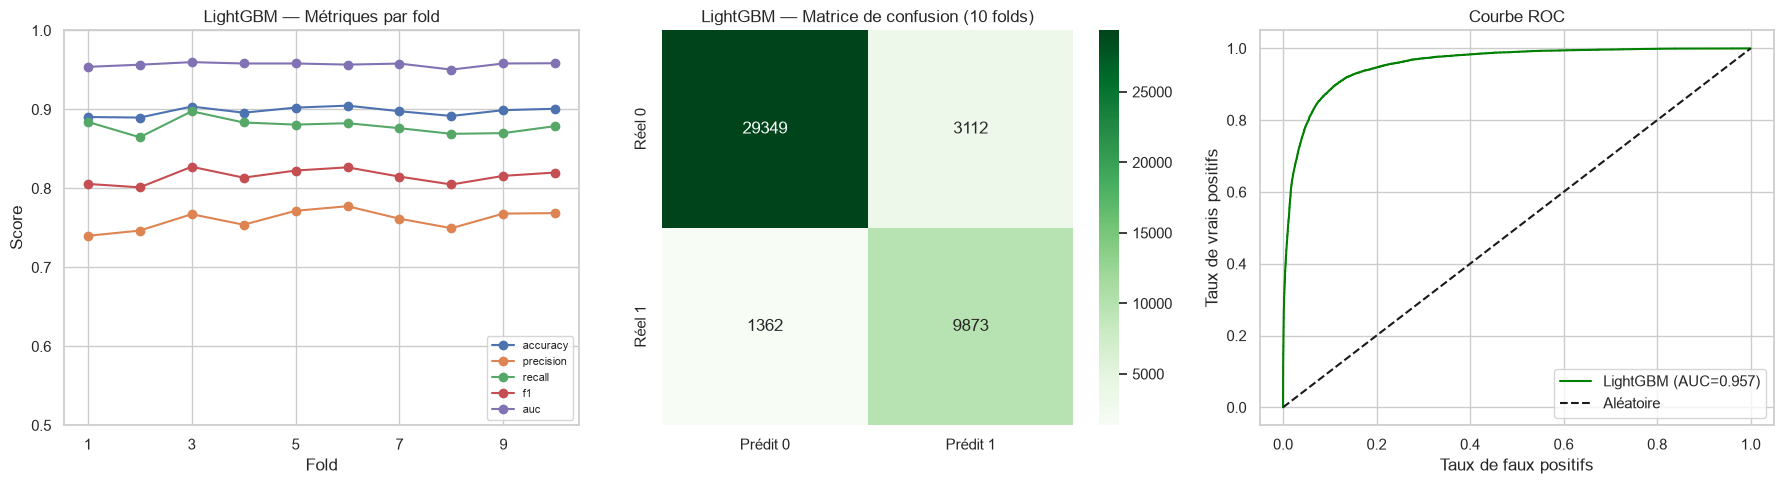

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Métriques par fold ---
ax = axes[0]
folds_plot = folds_df.drop(['mean', 'std']).drop(columns=['mcc'])
folds_plot.plot(ax=ax, marker='o')
ax.set_title('LightGBM — Métriques par fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right', fontsize=8)

# --- Matrice de confusion globale ---
ax = axes[1]
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
ax.set_title('LightGBM — Matrice de confusion (10 folds)')

# --- Courbe ROC ---
ax = axes[2]
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
auc_global  = roc_auc_score(all_y_true, all_y_prob)
ax.plot(fpr, tpr, label=f'LightGBM (AUC={auc_global:.3f})', color='green')
ax.plot([0,1],[0,1], 'k--', label='Aléatoire')
ax.set_title('Courbe ROC')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.legend()

plt.tight_layout()
plt.show()

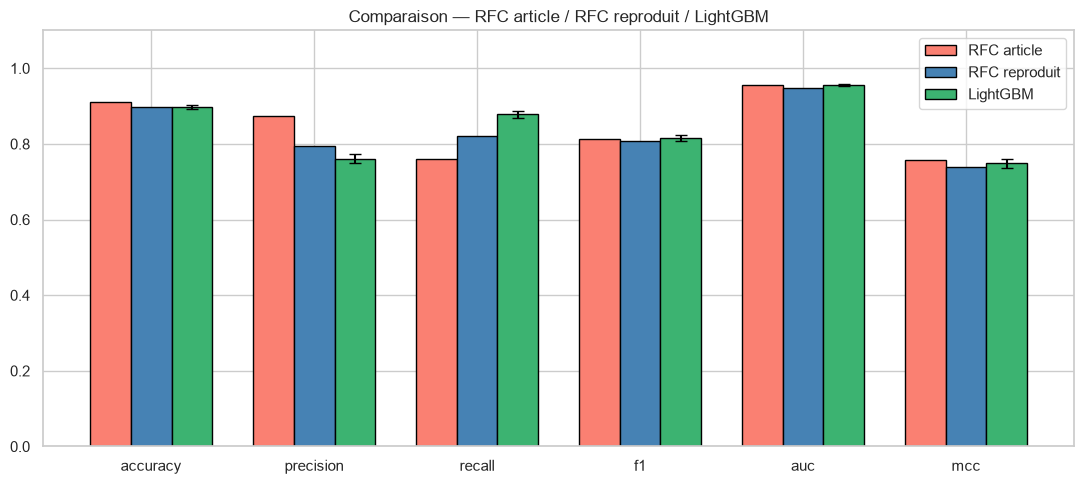

In [14]:
# Barplot 3 modèles côte à côte
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metric_keys))
w = 0.25

ax.bar(x - w,   [rfc_article[k]   for k in metric_keys], w, label='RFC article',    color='salmon',      edgecolor='black')
ax.bar(x,       [rfc_reproduit[k] for k in metric_keys], w, label='RFC reproduit',  color='steelblue',   edgecolor='black')
ax.bar(x + w,   [means[k]         for k in metric_keys], w, label='LightGBM',       color='mediumseagreen', edgecolor='black')
ax.errorbar(x + w, [means[k] for k in metric_keys],
            yerr=[stds[k] for k in metric_keys], fmt='none', color='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison — RFC article / RFC reproduit / LightGBM')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Importance des features (LightGBM)

In [15]:
# Entraîner sur tout X pour l'importance globale
lgbm_full = LGBMClassifier(
    n_estimators=250, learning_rate=0.1, num_leaves=31,
    class_weight='balanced', n_jobs=-1,
    random_state=RANDOM_STATE, verbosity=-1
)
lgbm_full.fit(X, y, feature_name=feat_names)

importances = pd.Series(
    lgbm_full.feature_importances_,
    index=feat_names
)

groups = {
    'squid (one-hot)': importances[importances.index.str.startswith('squid_')].sum(),
    **{f'w2v_{l}': importances[importances.index.str.startswith(f'w2v_{l}')].sum() for l in LINES}
}
print('Importance agrégée par groupe (gain) :')
for g, v in sorted(groups.items(), key=lambda x: -x[1]):
    print(f'  {g:20s} : {v:.1f}')

Importance agrégée par groupe (gain) :
  squid (one-hot)      : 2002.0
  w2v_line_0           : 1819.0
  w2v_line_m1          : 964.0
  w2v_line_m2          : 958.0
  w2v_line_1           : 897.0
  w2v_line_2           : 860.0


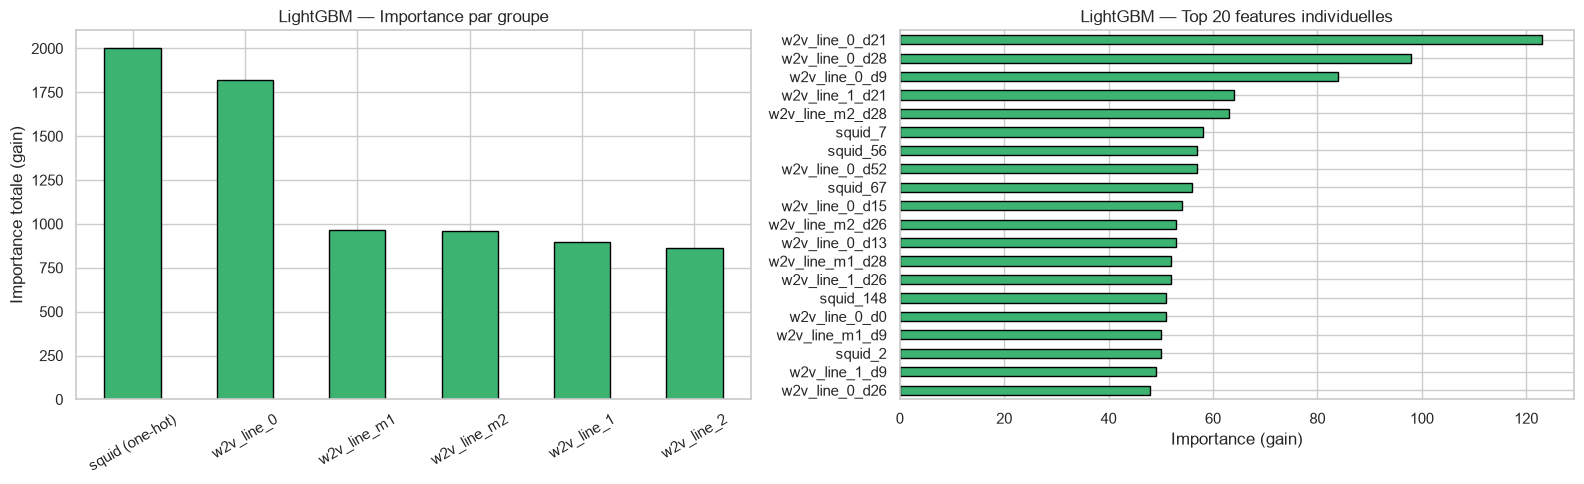

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
pd.Series(groups).sort_values(ascending=False).plot(
    kind='bar', ax=ax, edgecolor='black', color='mediumseagreen')
ax.set_title('LightGBM — Importance par groupe')
ax.set_ylabel('Importance totale (gain)')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
importances.nlargest(20).sort_values().plot(
    kind='barh', ax=ax, edgecolor='black', color='mediumseagreen')
ax.set_title('LightGBM — Top 20 features individuelles')
ax.set_xlabel('Importance (gain)')

plt.tight_layout()
plt.show()

## 8. Sauvegarde modèle et résultats

In [17]:
joblib.dump(lgbm_full, MODELS / 'lgbm_model.pkl')
print(f'Modèle sauvegardé : {MODELS / "lgbm_model.pkl"}')

results_lgbm = {
    'model'       : 'LGBMClassifier',
    'hyperparams' : {
        'n_estimators': 250, 'learning_rate': 0.1,
        'num_leaves': 31, 'class_weight': 'balanced'
    },
    'cv'          : '10-fold StratifiedKFold',
    'n_samples'   : int(X.shape[0]),
    'n_features'  : int(X.shape[1]),
    'fold_metrics': fold_results,
    'mean_metrics': {k: round(float(v), 4) for k, v in means.items()},
    'std_metrics' : {k: round(float(v), 4) for k, v in stds.items()},
    'rfc_article' : rfc_article,
    'rfc_reproduit': rfc_reproduit,
    'delta_vs_rfc_article': {k: round(float(means[k] - rfc_article[k]), 4) for k in metric_keys},
    'delta_vs_rfc_reproduit': {k: round(float(means[k] - rfc_reproduit[k]), 4) for k in metric_keys},
}

with open(RESULTS / 'results_lgbm.json', 'w', encoding='utf-8') as f:
    json.dump(results_lgbm, f, indent=2, ensure_ascii=False)

print(f'Résultats sauvegardés : {RESULTS / "results_lgbm.json"}')
print()
print('=== Résumé final ===')
for k in metric_keys:
    d_art  = means[k] - rfc_article[k]
    d_rfc  = means[k] - rfc_reproduit[k]
    print(f'  {k:12s} : {means[k]:.4f} ± {stds[k]:.4f}  '
          f'(Δ art. {"+" if d_art>=0 else ""}{d_art:.4f}  '
          f'Δ RFC {"+" if d_rfc>=0 else ""}{d_rfc:.4f})')

Modèle sauvegardé : C:\Projects\SonarQube_FP\models\lgbm_model.pkl
Résultats sauvegardés : C:\Projects\SonarQube_FP\results\results_lgbm.json

=== Résumé final ===
  accuracy     : 0.8976 ± 0.0052  (Δ art. -0.0124  Δ RFC -0.0012)
  precision    : 0.7605 ± 0.0117  (Δ art. -0.1134  Δ RFC -0.0328)
  recall       : 0.8788 ± 0.0090  (Δ art. +0.1190  Δ RFC +0.0582)
  f1           : 0.8153 ± 0.0087  (Δ art. +0.0026  Δ RFC +0.0087)
  auc          : 0.9569 ± 0.0026  (Δ art. +0.0018  Δ RFC +0.0098)
  mcc          : 0.7488 ± 0.0120  (Δ art. -0.0084  Δ RFC +0.0104)
